## Convert data with `pygid`

In [1]:
import pygid

exp_metadata = pygid.ExpMetadata(
    start_time = r"2025-09-09T20:36:23.076828",
    end_time    = r"2025-09-09T20:37:24.076828",
    source_type = "synchrotron",
    source_name = "ESRF ID10",
    detector = "eiger4m",
    monitor = 294302)

smpl_metadata = pygid.SampleMetadata(path_to_load="sample.yaml")

INFO - Saved in /home/ainurabukaev/data/Programming/mlgid/mlgidBASE/example/result_from_file.h5 in group entry_0000


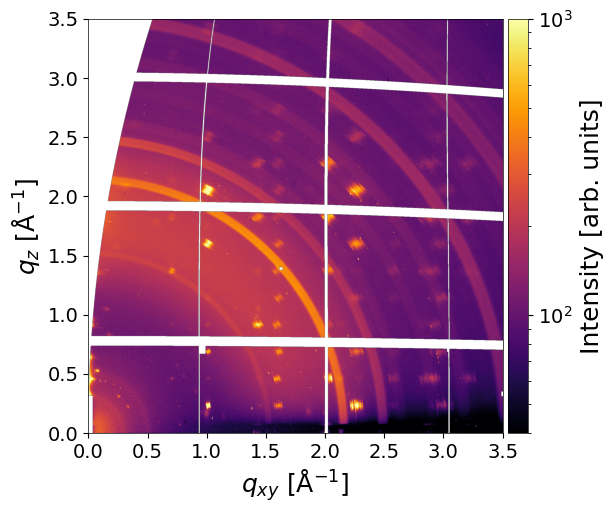

In [2]:
poni_path = './laB6_2025_09_05.poni'
mask_path = './mask.npy'
filename = './eiger4m_0000.h5'
dataset = '/entry/data0/image'
frame_num = None

params = pygid.ExpParams(
	poni_path = poni_path,
    mask_path = mask_path,
    fliplr = True,
    flipud = True,
    # transp = False,
    ai = 0.075
)

matrix = pygid.CoordMaps(
    params,
    vert_positive = True, hor_positive = True,
    q_xy_range = (0, 3.5), q_z_range = (0, 3.5), dq = 0.002,
)

conversion = pygid.Conversion(
    matrix = matrix,
    path = filename,
    dataset = dataset,
    frame_num = frame_num
)

conversion.det2q_gid(clims = (40, 1000),
    plot_result = True, return_result = False,
    save_result = True, path_to_save = "result_from_file.h5",
    overwrite_file = True, h5_group = "entry_0000",
    overwrite_group = False,
    smpl_metadata = smpl_metadata, exp_metadata=exp_metadata
)


## From file

In [3]:
from mlgidbase import mlgidBASE
filename = r'result_from_file.h5'
analysis = mlgidBASE(filename = filename)

In [4]:
analysis.run_detection()

INFO - Loading model
INFO - Using the GPU for inference
INFO - Saved detected peaks to file: result_from_file.h5, entry: entry_0000, frame: 0


In [5]:
analysis.run_fitting()

INFO - Saved fitted peaks to file: result_from_file.h5, entry: entry_0000, frame: 0


In [6]:
cif_prepr = r'prepr_cifs.pickle'
analysis.run_matching(cif_prepr = cif_prepr, peaks_type='rings', threshold=0.9,
                      device = 'cuda')

INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0000, frame: 0


In [7]:
analysis.run_matching(cif_prepr = cif_prepr, peaks_type='segments', threshold=0.9)

INFO - cif_prepr is already set. The previous cif_prepr is to be used
INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0000, frame: 0


INFO - Saved figure in /home/ainurabukaev/data/Programming/mlgid/mlgidBASE/example/img_entry_0000_fr_0000_sol_0000.png


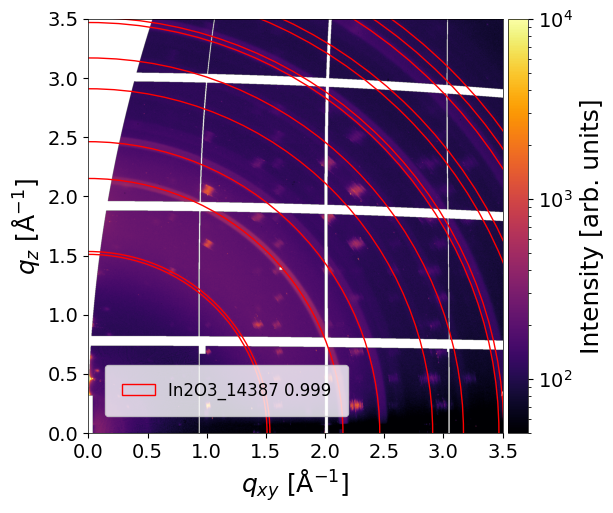

INFO - Saved figure in /home/ainurabukaev/data/Programming/mlgid/mlgidBASE/example/img_entry_0000_fr_0000_sol_0001.png


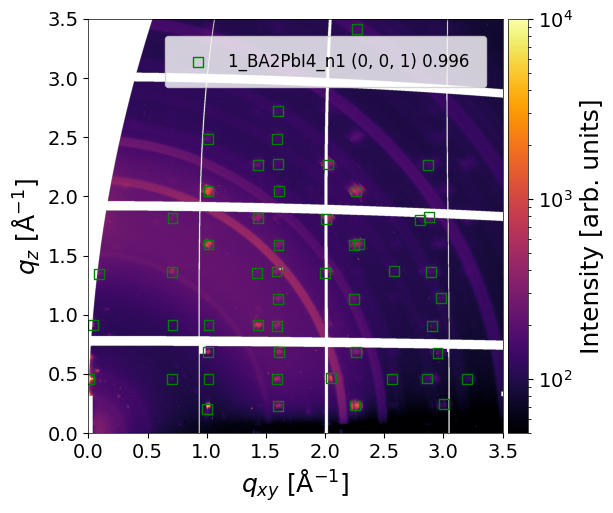

In [8]:
analysis.plot_analysis_results(
                              detected_params = {'line_width': 0.5,
                                               'line_style': "--",
                                               'line_color': "black",
                                               'plot': False},
                              fitted_params = {'plot_segments': True,
                                               'marker': 'o',
                                               'marker_size': 50,
                                               'marker_facecolor': "none",
                                               'marker_edgecolor': "bone",
                                               'plot_rings': True,
                                               'line_width': 1,
                                               'line_style': "--",
                                               'line_color': "bone",
                                               'plot': False,
                                               'intensity_threshold': 0},
                              matched_params = {'plot_segments': True,
                                               'marker': ['s'],
                                               'marker_size': [50],
                                               'marker_facecolor': ["none"],
                                               'marker_edgecolor': ["green", "red"],
                                               'plot_rings': True,
                                               'line_width': [1],
                                               'line_style': ["-", "--"],
                                               'line_color': ["red", "green"],
                                               'plot': True,
                                               'legend': True,
                                                'probability_threshold': 0},
                              frame_num = 0, entry = 'entry_0000',
                              return_result=False, plot_result=True,
                              clims=(50, 1e4), xlim=(None, None), ylim=(None, None),
                              save_fig=True, path_to_save_fig="img.png")

## From `pygid.Conversion`

In [17]:
from mlgidbase import mlgidBASE
analysis = mlgidBASE(pygid_conversion = conversion)

In [18]:
analysis.run_detection()

INFO - Loading model
INFO - Using the GPU for inference


In [28]:
analysis.run_fitting()

In [20]:
analysis.run_matching(cif_prepr = r'prepr_cifs.pickle', peaks_type='segments', probability_threshold=0.9,
                      intensity_threshold=10)

In [31]:
analysis.run_matching(cif_prepr = r'prepr_cifs.pickle', peaks_type='rings', probability_threshold=0.5,)

INFO - cif_prepr is already set. The previous cif_prepr is to be used


INFO - Saved figure in /home/ainurabukaev/data/Programming/mlgid/mlgidBASE/example/img.png


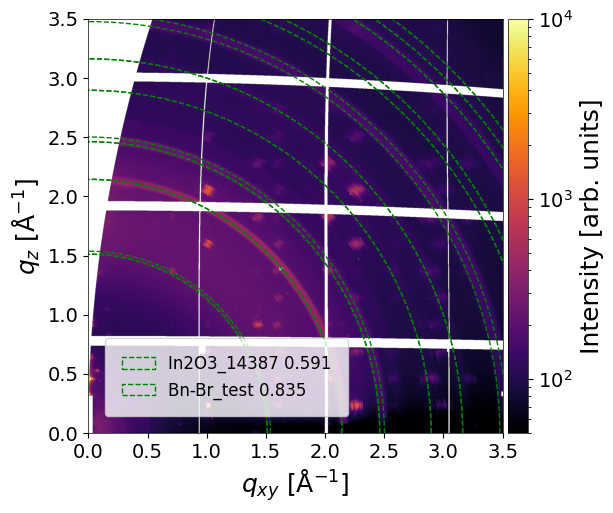

In [33]:
analysis.plot_analysis_results(
                              detected_params = {'line_width': 0.5,
                                               'line_style': "--",
                                               'line_color': "black",
                                               'plot': False},
                              fitted_params = {'plot_segments': True,
                                               'marker': 'o',
                                               'marker_size': 50,
                                               'marker_facecolor': "none",
                                               'marker_edgecolor': "bone",
                                               'plot_rings': True,
                                               'line_width': 1,
                                               'line_style': "--",
                                               'line_color': "bone",
                                               'plot': False},
                              matched_params = {'plot_segments': True,
                                               'marker': ['s'],
                                               'marker_size': [50],
                                               'marker_facecolor': ["none"],
                                               'marker_edgecolor': ["green", "red"],
                                               'plot_rings': True,
                                               'line_width': [1],
                                               'line_style': ["--"],
                                               'line_color': ["green"],
                                               'plot': True,
                                               'legend': True},
                              frame_num = None, entry = None,
                              return_result=False, plot_result=True,
                              clims=(50, 1e4), xlim=(None, None), ylim=(None, None),
                              save_fig=True, path_to_save_fig="img.png")

In [32]:
analysis.container_match_list

[ContainerMatched(results_arrays=[array([(b'In2O3_14387.cif', 0, 0, 0, 0.59091866, array([18, 20, 21, 28, 32, 41, 49, 54, 61, 72], dtype=int32)),
        (b'Bn-Br_test.cif', 0, 0, 0, 0.83456814, array([15, 18, 19, 20, 21, 28, 32, 41, 49, 54, 61, 62, 65, 72],
              dtype=int32))                                                                                     ],
       dtype=[('CIF', 'S64'), ('h', '<i4'), ('k', '<i4'), ('l', '<i4'), ('probability', '<f4'), ('peak_list', 'O')])], field_names=['matched_rings_0000'], metadata={'program': 'mlgidmatch', 'version': '0.1.1', 'date': '2026-04-07T17:04:49.566626', 'probability_threshold': 0.5, 'peaks_type': 'rings', 'intensity_threshold': 0, 'CIFs': ['MAPbBr3_1533441.cif', 'SnO2_39173.cif', '576_PEA2PbI4_n1.cif', '579_PEA2MAPb2I7_n2.cif', 'hex_4H_S41.cif', 'SnO_15516.cif', 'SnO2_9163.cif', '581_BA2FAPb2I7_n2.cif', '5_BA2MAPb2I7_n2.cif', '1_BA2PbI4_n1.cif', 'hex_2H_S41.cif', 'SnO_16481.cif', 'hex_6H_S41.cif', '6_BA2MA2Pb3I10_n3.cif', 'I

In [14]:
analysis.save_result(path_to_save='result_from_conversion.h5',
                     # smpl_metadata = smpl_metadata, exp_metadata=exp_metadata,
                     save_polar=True)

INFO - Saved in /home/ainurabukaev/data/Programming/mlgid/mlgidBASE/example/result_from_conversion.h5 in group entry_0000
INFO - Saved in /home/ainurabukaev/data/Programming/mlgid/mlgidBASE/example/result_from_conversion.h5 in group entry_polar_0000
